In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
df=pd.read_csv("/Users/himanshu/Downloads/SUL_project/diabetic_data.csv")

In [42]:

print(df.shape)


(101766, 50)


In [43]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [44]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [46]:
df.replace("?",np.nan,inplace=True)

In [47]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [48]:
missing = df.isnull().sum()

print(missing)

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [49]:
for col in ["diag_1", "diag_2", "diag_3"]:
    df[col].fillna("Unknown", inplace=True)

/var/folders/v5/2bjvrdz97pg0zr3_lz94y98c0000gn/T/ipykernel_1876/1851825839.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna("Unknown", inplace=True)


In [50]:
df["race"].fillna(df["race"].mode()[0], inplace=True)

/var/folders/v5/2bjvrdz97pg0zr3_lz94y98c0000gn/T/ipykernel_1876/717425234.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["race"].fillna(df["race"].mode()[0], inplace=True)


In [51]:
missing = df.isnull().sum()
print(missing)


encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

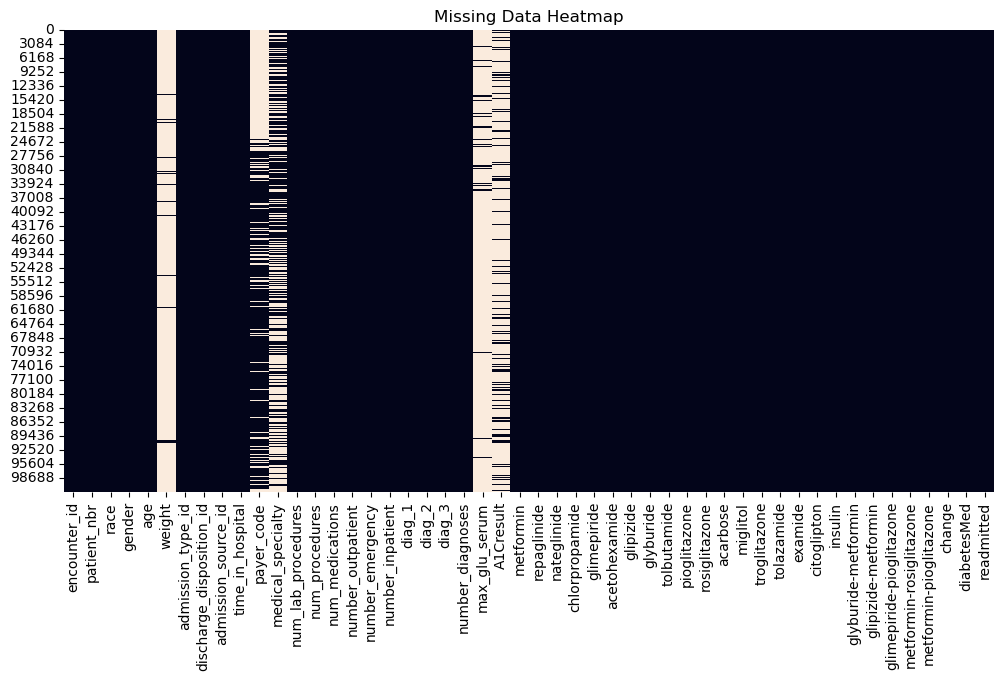

In [53]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Data Heatmap")
plt.show()

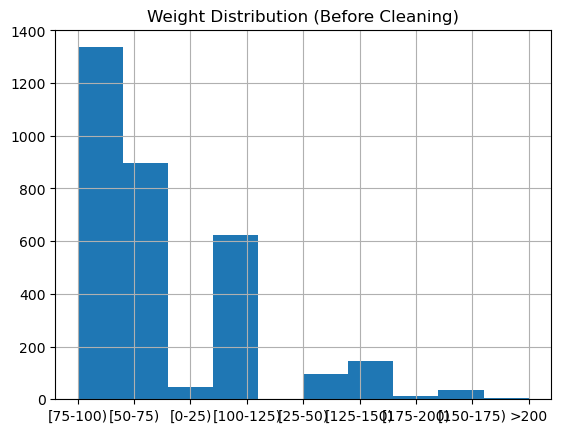

In [54]:
df["weight"].hist()
plt.title("Weight Distribution (Before Cleaning)")
plt.show()

In [55]:
df.drop(columns=["weight","max_glu_serum","A1Cresult"],inplace=True,errors="ignore")
cat_cols = df.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1',
       'diag_2', 'diag_3', 'metformin', 'repaglinide', 'nateglinide',
       'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide',
       'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
       'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton',
       'insulin', 'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')


In [56]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

binary_cols = ["gender", "change", "diabetesMed"]

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [57]:
mapping = {
    "No": 0,
    "Steady": 1,
    "Up": 2,
    "Down": 3
}

med_cols = [
    "metformin","repaglinide","nateglinide","chlorpropamide",
    "glimepiride","acetohexamide","glipizide","glyburide",
    "tolbutamide","pioglitazone","rosiglitazone","acarbose",
    "miglitol","troglitazone","tolazamide","examide",
    "citoglipton","insulin","glyburide-metformin",
    "glipizide-metformin","glimepiride-pioglitazone",
    "metformin-rosiglitazone","metformin-pioglitazone"
]

for col in med_cols:
    df[col] = df[col].map(mapping)

In [58]:
remaining_cols = df.select_dtypes(include=['object']).columns

for col in remaining_cols:
    df[col] = le.fit_transform(df[col])

In [59]:
print(df.dtypes)


encounter_id                int64
patient_nbr                 int64
race                        int64
gender                      int64
age                         int64
admission_type_id           int64
discharge_disposition_id    int64
admission_source_id         int64
time_in_hospital            int64
payer_code                  int64
medical_specialty           int64
num_lab_procedures          int64
num_procedures              int64
num_medications             int64
number_outpatient           int64
number_emergency            int64
number_inpatient            int64
diag_1                      int64
diag_2                      int64
diag_3                      int64
number_diagnoses            int64
metformin                   int64
repaglinide                 int64
nateglinide                 int64
chlorpropamide              int64
glimepiride                 int64
acetohexamide               int64
glipizide                   int64
glyburide                   int64
tolbutamide   

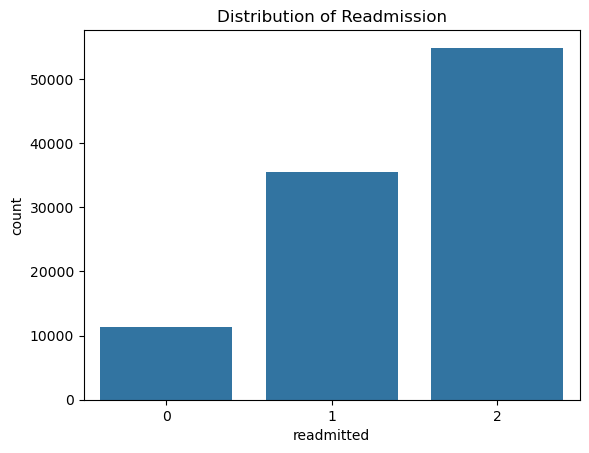

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df["readmitted"])
plt.title("Distribution of Readmission")
plt.show()

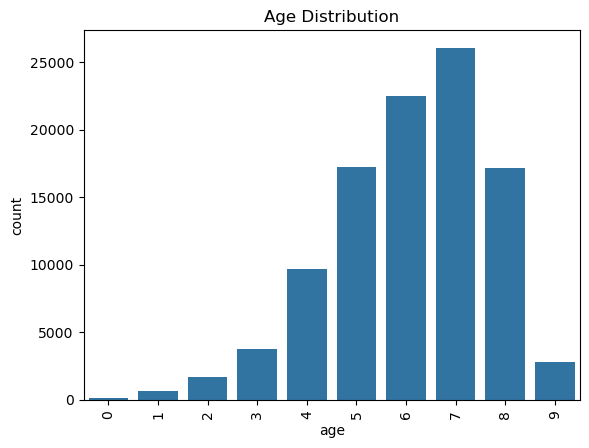

In [61]:
sns.countplot(x=df["age"])
plt.xticks(rotation=90)
plt.title("Age Distribution")
plt.show()

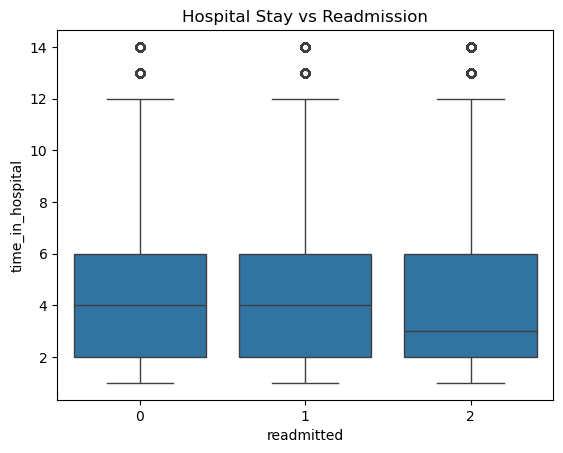

In [62]:
sns.boxplot(x=df["readmitted"], y=df["time_in_hospital"])
plt.title("Hospital Stay vs Readmission")
plt.show()

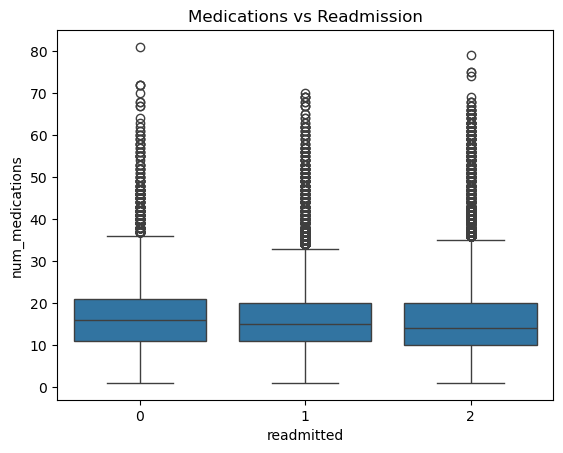

In [63]:
sns.boxplot(x=df["readmitted"], y=df["num_medications"])
plt.title("Medications vs Readmission")
plt.show()

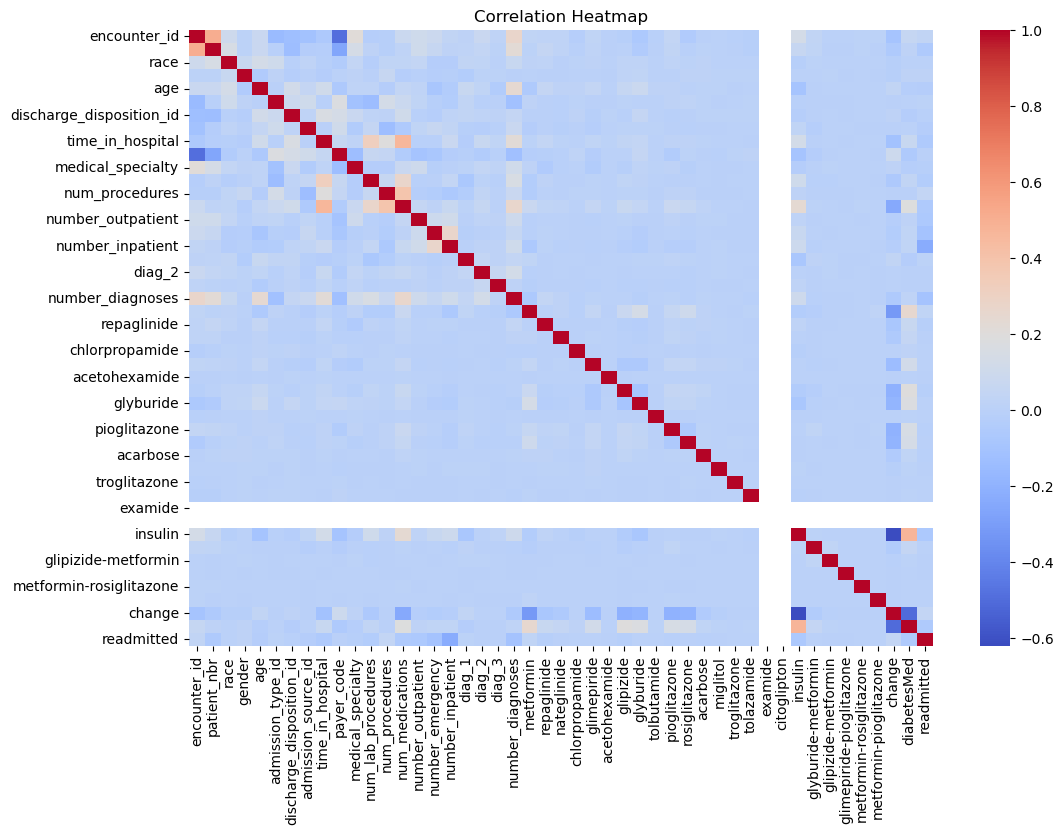

In [64]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

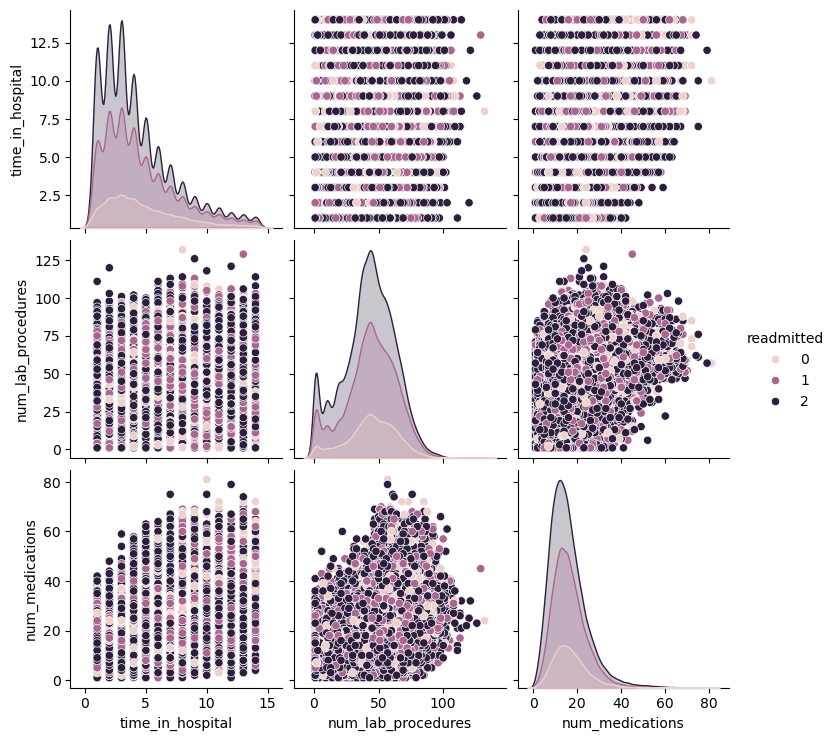

In [65]:
sample_df = df[["time_in_hospital", "num_lab_procedures", "num_medications", "readmitted"]]

sns.pairplot(sample_df, hue="readmitted")
plt.show()

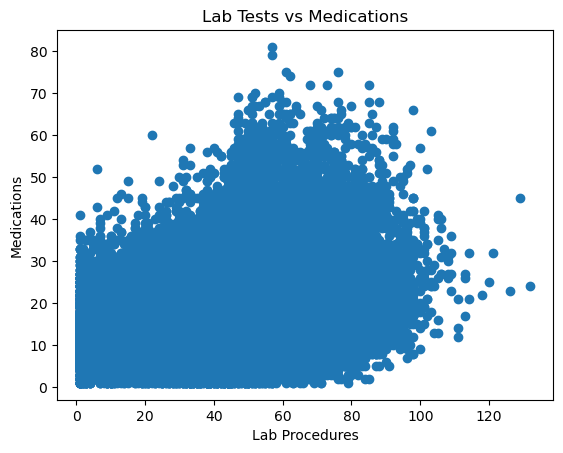

In [66]:
plt.scatter(df["num_lab_procedures"], df["num_medications"])
plt.xlabel("Lab Procedures")
plt.ylabel("Medications")
plt.title("Lab Tests vs Medications")
plt.show()

In [67]:
df.isnull().sum().sum()

np.int64(0)

In [68]:
df.to_csv("Cleaned_dataset.csv")

In [69]:
X = df.drop("readmitted", axis=1)
y = df["readmitted"]

In [70]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
X_var = selector.fit_transform(X)

# keep only selected columns
selected_cols = X.columns[selector.get_support()]
X = X[selected_cols]

print("Remaining features:", X.shape[1])

Remaining features: 31


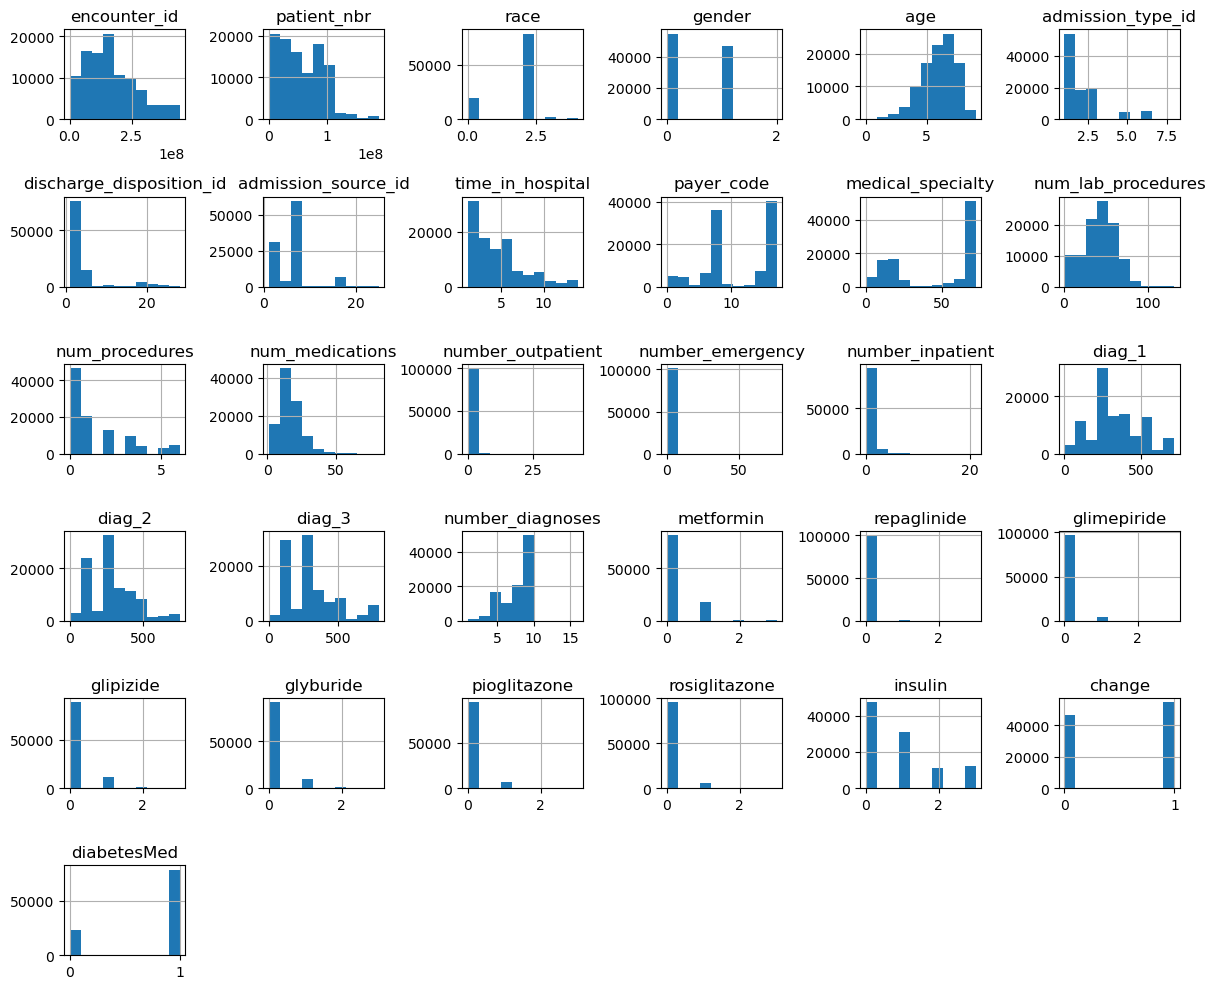

In [71]:
import matplotlib.pyplot as plt

X.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

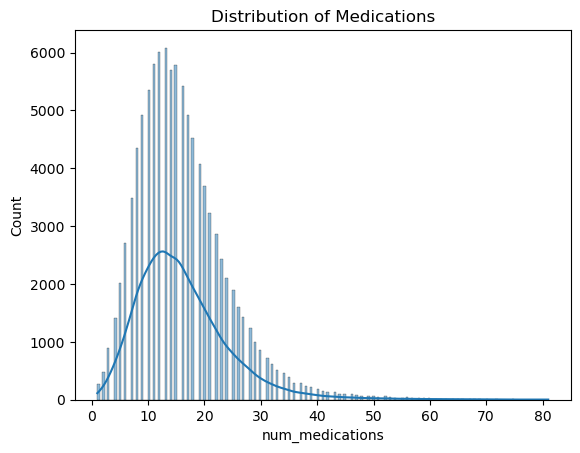

In [72]:
import seaborn as sns

sns.histplot(df["num_medications"], kde=True)
plt.title("Distribution of Medications")
plt.show()

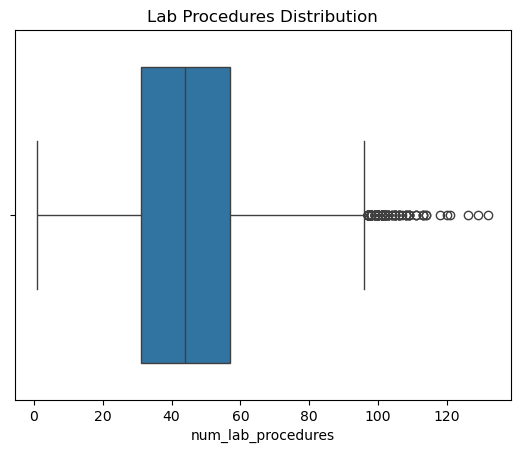

In [73]:
sns.boxplot(x=df["num_lab_procedures"])
plt.title("Lab Procedures Distribution")
plt.show()

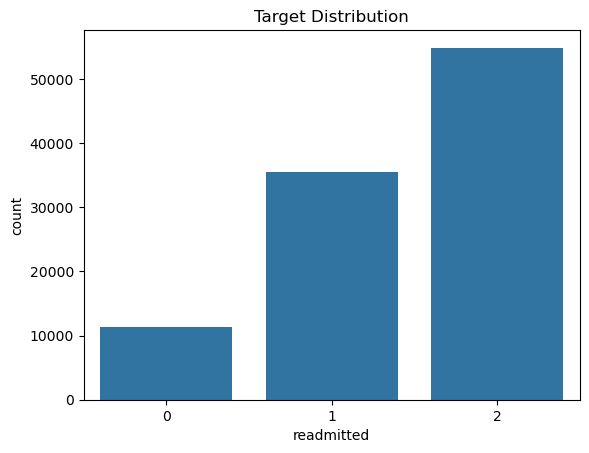

In [74]:
sns.countplot(x=df["readmitted"])
plt.title("Target Distribution")
plt.show()

In [75]:
print(X.skew().sort_values(ascending=False))

number_emergency            22.855582
repaglinide                 10.410398
number_outpatient            8.832959
glimepiride                  5.643744
rosiglitazone                4.445323
pioglitazone                 4.187242
glyburide                    3.902517
number_inpatient             3.614139
glipizide                    3.459539
discharge_disposition_id     2.563067
metformin                    2.416975
admission_type_id            1.591984
num_medications              1.326672
num_procedures               1.316415
time_in_hospital             1.133999
diag_3                       1.042775
admission_source_id          1.029935
insulin                      0.905163
diag_2                       0.752120
encounter_id                 0.699142
patient_nbr                  0.471281
diag_1                       0.378771
gender                       0.151368
change                      -0.152637
payer_code                  -0.183538
num_lab_procedures          -0.236544
medical_spec

In [76]:
df.to_csv("Cleaned_dataset_1.csv")